### Retail Sales Forecasting
This project builds a machine learning model to forecast retail sales using historical transaction data, promotions, oil prices, and store information.
The objective is to understand key factors that influence sales and develop a model that can predict future sales accurately.

### Data Loading

The raw datasets are loaded into the environment. These datasets include historical sales data, store information, transaction counts, oil prices, and holiday information.

In [1]:
import pandas as pd

In [2]:
train_raw = pd.read_csv("train.csv")

In [3]:
test_raw = pd.read_csv("test.csv")

In [4]:
stores_raw = pd.read_csv("stores.csv")

In [5]:
transactions_raw = pd.read_csv("transactions.csv")

In [6]:
oil_raw = pd.read_csv("oil.csv")

In [7]:
holidays_raw = pd.read_csv("holidays.csv")

### Data Validation

A quick inspection is performed to verify dataset structure, column names, and overall data quality before beginning any cleaning or transformations.

In [8]:
def load_check(df, name):
    print(f"\n{name}")
    print("shape:", df.shape)
    print("Data Types:")
    print(df.dtypes)
    print("\nFirst 5 rows:")
    print(df.head())

In [89]:
load_check(train_raw, "Train Raw Table")


Train Raw Table
shape: (3000888, 6)
Data Types:
id               int64
date            object
store_nbr        int64
family          object
sales          float64
onpromotion      int64
dtype: object

First 5 rows:
   id        date  store_nbr      family  sales  onpromotion
0   0  2013-01-01          1  AUTOMOTIVE   0.00            0
1   1  2013-01-01          1   BABY CARE   0.00            0
2   2  2013-01-01          1      BEAUTY   0.00            0
3   3  2013-01-01          1   BEVERAGES   0.00            0
4   4  2013-01-01          1       BOOKS   0.00            0


In [10]:
load_check(test_raw, "Test Raw Table")


Test Raw Table
shape: (28512, 5)
Data Types:
id              int64
date           object
store_nbr       int64
family         object
onpromotion     int64
dtype: object

First 5 rows:
        id        date  store_nbr      family  onpromotion
0  3000888  2017-08-16          1  AUTOMOTIVE            0
1  3000889  2017-08-16          1   BABY CARE            0
2  3000890  2017-08-16          1      BEAUTY            2
3  3000891  2017-08-16          1   BEVERAGES           20
4  3000892  2017-08-16          1       BOOKS            0


In [11]:
load_check(stores_raw, "Stores Raw Table")


Stores Raw Table
shape: (54, 5)
Data Types:
store_nbr     int64
city         object
state        object
type         object
cluster       int64
dtype: object

First 5 rows:
   store_nbr           city                           state type  cluster
0          1          Quito                       Pichincha    D       13
1          2          Quito                       Pichincha    D       13
2          3          Quito                       Pichincha    D        8
3          4          Quito                       Pichincha    D        9
4          5  Santo Domingo  Santo Domingo de los Tsachilas    D        4


In [12]:
load_check(transactions_raw, "Transaction Raw Table")


Transaction Raw Table
shape: (83488, 3)
Data Types:
date            object
store_nbr        int64
transactions     int64
dtype: object

First 5 rows:
         date  store_nbr  transactions
0  2013-01-01         25           770
1  2013-01-02          1          2111
2  2013-01-02          2          2358
3  2013-01-02          3          3487
4  2013-01-02          4          1922


In [13]:
load_check(oil_raw, "oil Raw Table")


oil Raw Table
shape: (1218, 2)
Data Types:
date           object
dcoilwtico    float64
dtype: object

First 5 rows:
         date  dcoilwtico
0  2013-01-01         NaN
1  2013-01-02       93.14
2  2013-01-03       92.97
3  2013-01-04       93.12
4  2013-01-07       93.20


In [14]:
load_check(holidays_raw, "holidays Raw Table")


holidays Raw Table
shape: (350, 6)
Data Types:
date           object
type           object
locale         object
locale_name    object
description    object
transferred      bool
dtype: object

First 5 rows:
         date     type    locale locale_name                    description  \
0  2012-03-02  Holiday     Local       Manta             Fundacion de Manta   
1  2012-04-01  Holiday  Regional    Cotopaxi  Provincializacion de Cotopaxi   
2  2012-04-12  Holiday     Local      Cuenca            Fundacion de Cuenca   
3  2012-04-14  Holiday     Local    Libertad      Cantonizacion de Libertad   
4  2012-04-21  Holiday     Local    Riobamba      Cantonizacion de Riobamba   

   transferred  
0        False  
1        False  
2        False  
3        False  
4        False  


##  Data Cleaning and Staging

Copies of the raw datasets are created to allow safe data cleaning and transformations without modifying the original raw data.

In [15]:
train_staging = train_raw.copy()

In [16]:
test_staging = test_raw.copy()

In [17]:
stores_staging = stores_raw.copy()

In [18]:
transactions_staging = transactions_raw.copy()

In [19]:
oil_staging = oil_raw.copy()

In [20]:
holidays_staging = holidays_raw.copy()

## Data Quality Checks

The staging datasets are examined for missing values, data types, and potential inconsistencies that may affect analysis or modeling.

In [21]:
def quick_check(df, name):
    print(f"\n{name}")
    print("-" * 50)

    print("shape:")
    print(df.shape)

    print("\nData types:")
    print(df.dtypes)

    print("\nMissing Values:")
    print(df.isnull().sum())

    print("\nDuplicate Rows:")
    print(df.duplicated().sum())

    print("\nFirst 5 Rows:")
    print(df.head())

    print("\nSummary Statistics:")
    print(df.describe())
    pd.options.display.float_format = '{:,.2f}'.format

In [22]:
quick_check(train_staging, "Train Staging Table")


Train Staging Table
--------------------------------------------------
shape:
(3000888, 6)

Data types:
id               int64
date            object
store_nbr        int64
family          object
sales          float64
onpromotion      int64
dtype: object

Missing Values:
id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64

Duplicate Rows:
0

First 5 Rows:
   id        date  store_nbr      family  sales  onpromotion
0   0  2013-01-01          1  AUTOMOTIVE    0.0            0
1   1  2013-01-01          1   BABY CARE    0.0            0
2   2  2013-01-01          1      BEAUTY    0.0            0
3   3  2013-01-01          1   BEVERAGES    0.0            0
4   4  2013-01-01          1       BOOKS    0.0            0

Summary Statistics:
                 id     store_nbr         sales   onpromotion
count  3.000888e+06  3.000888e+06  3.000888e+06  3.000888e+06
mean   1.500444e+06  2.750000e+01  3.577757e+02  2.602770e+00
std 

In [23]:
quick_check(test_staging, "Test Staging Table")


Test Staging Table
--------------------------------------------------
shape:
(28512, 5)

Data types:
id              int64
date           object
store_nbr       int64
family         object
onpromotion     int64
dtype: object

Missing Values:
id             0
date           0
store_nbr      0
family         0
onpromotion    0
dtype: int64

Duplicate Rows:
0

First 5 Rows:
        id        date  store_nbr      family  onpromotion
0  3000888  2017-08-16          1  AUTOMOTIVE            0
1  3000889  2017-08-16          1   BABY CARE            0
2  3000890  2017-08-16          1      BEAUTY            2
3  3000891  2017-08-16          1   BEVERAGES           20
4  3000892  2017-08-16          1       BOOKS            0

Summary Statistics:
                id  store_nbr  onpromotion
count    28,512.00  28,512.00    28,512.00
mean  3,015,143.50      27.50         6.97
std       8,230.85      15.59        20.68
min   3,000,888.00       1.00         0.00
25%   3,008,015.75      14.00      

In [24]:
quick_check(stores_staging, "Stores Staging Table")


Stores Staging Table
--------------------------------------------------
shape:
(54, 5)

Data types:
store_nbr     int64
city         object
state        object
type         object
cluster       int64
dtype: object

Missing Values:
store_nbr    0
city         0
state        0
type         0
cluster      0
dtype: int64

Duplicate Rows:
0

First 5 Rows:
   store_nbr           city                           state type  cluster
0          1          Quito                       Pichincha    D       13
1          2          Quito                       Pichincha    D       13
2          3          Quito                       Pichincha    D        8
3          4          Quito                       Pichincha    D        9
4          5  Santo Domingo  Santo Domingo de los Tsachilas    D        4

Summary Statistics:
       store_nbr  cluster
count      54.00    54.00
mean       27.50     8.48
std        15.73     4.69
min         1.00     1.00
25%        14.25     4.00
50%        27.50     8.50

In [25]:
quick_check(transactions_staging, "Transactions Staging Table")


Transactions Staging Table
--------------------------------------------------
shape:
(83488, 3)

Data types:
date            object
store_nbr        int64
transactions     int64
dtype: object

Missing Values:
date            0
store_nbr       0
transactions    0
dtype: int64

Duplicate Rows:
0

First 5 Rows:
         date  store_nbr  transactions
0  2013-01-01         25           770
1  2013-01-02          1          2111
2  2013-01-02          2          2358
3  2013-01-02          3          3487
4  2013-01-02          4          1922

Summary Statistics:
       store_nbr  transactions
count  83,488.00     83,488.00
mean       26.94      1,694.60
std        15.61        963.29
min         1.00          5.00
25%        13.00      1,046.00
50%        27.00      1,393.00
75%        40.00      2,079.00
max        54.00      8,359.00


In [26]:
quick_check(oil_staging, "oil Staging Table")


oil Staging Table
--------------------------------------------------
shape:
(1218, 2)

Data types:
date           object
dcoilwtico    float64
dtype: object

Missing Values:
date           0
dcoilwtico    43
dtype: int64

Duplicate Rows:
0

First 5 Rows:
         date  dcoilwtico
0  2013-01-01         NaN
1  2013-01-02       93.14
2  2013-01-03       92.97
3  2013-01-04       93.12
4  2013-01-07       93.20

Summary Statistics:
       dcoilwtico
count    1,175.00
mean        67.71
std         25.63
min         26.19
25%         46.41
50%         53.19
75%         95.66
max        110.62


In [27]:
quick_check(holidays_staging, "Holidays Staging Table")


Holidays Staging Table
--------------------------------------------------
shape:
(350, 6)

Data types:
date           object
type           object
locale         object
locale_name    object
description    object
transferred      bool
dtype: object

Missing Values:
date           0
type           0
locale         0
locale_name    0
description    0
transferred    0
dtype: int64

Duplicate Rows:
0

First 5 Rows:
         date     type    locale locale_name                    description  \
0  2012-03-02  Holiday     Local       Manta             Fundacion de Manta   
1  2012-04-01  Holiday  Regional    Cotopaxi  Provincializacion de Cotopaxi   
2  2012-04-12  Holiday     Local      Cuenca            Fundacion de Cuenca   
3  2012-04-14  Holiday     Local    Libertad      Cantonizacion de Libertad   
4  2012-04-21  Holiday     Local    Riobamba      Cantonizacion de Riobamba   

   transferred  
0        False  
1        False  
2        False  
3        False  
4        False  

Summar

In [28]:
train_staging[train_staging['sales'] < 0]

,id,date,store_nbr,family,sales,onpromotion


In [29]:
(train_staging['sales'] < 0).sum()

np.int64(0)

In [30]:
(train_staging['sales'] == 0).sum()

np.int64(939130)

In [31]:
train_staging['date'].min()

'2013-01-01'

In [32]:
train_staging['date'].max()

'2017-08-15'

In [33]:
train_staging['family'].nunique()

33

In [34]:
train_staging['family'].unique()

array(['AUTOMOTIVE', 'BABY CARE', 'BEAUTY', 'BEVERAGES', 'BOOKS',
       'BREAD/BAKERY', 'CELEBRATION', 'CLEANING', 'DAIRY', 'DELI', 'EGGS',
       'FROZEN FOODS', 'GROCERY I', 'GROCERY II', 'HARDWARE',
       'HOME AND KITCHEN I', 'HOME AND KITCHEN II', 'HOME APPLIANCES',
       'HOME CARE', 'LADIESWEAR', 'LAWN AND GARDEN', 'LINGERIE',
       'LIQUOR,WINE,BEER', 'MAGAZINES', 'MEATS', 'PERSONAL CARE',
       'PET SUPPLIES', 'PLAYERS AND ELECTRONICS', 'POULTRY',
       'PREPARED FOODS', 'PRODUCE', 'SCHOOL AND OFFICE SUPPLIES',
       'SEAFOOD'], dtype=object)

In [35]:
train_staging['date'] =pd.to_datetime(train_staging['date'])
test_staging['date'] =pd.to_datetime(test_staging['date'])
transactions_staging['date'] =pd.to_datetime(transactions_staging['date'])
oil_staging['date'] =pd.to_datetime(oil_staging['date'])
holidays_staging['date'] =pd.to_datetime(holidays_staging['date'])

In [36]:
oil_staging['dcoilwtico'] = oil_staging['dcoilwtico'].interpolate().bfill()

In [37]:
oil_staging.isnull().sum()

date          0
dcoilwtico    0
dtype: int64

In [38]:
train_merged = pd.merge(train_staging, stores_staging, how='left', left_on='store_nbr', right_on='store_nbr')

In [39]:
train_merged = pd.merge(train_merged, transactions_staging, how='left', left_on=['store_nbr', 'date'], right_on=['store_nbr', 'date'])

In [40]:
train_merged = pd.merge(train_merged, oil_staging, how='left', left_on='date', right_on='date')

In [41]:
holidays_flag = holidays_staging[['date']].drop_duplicates()
holidays_flag['is_holiday'] = 1
train_merged = pd.merge(train_merged, holidays_flag, on="date", how="left")

In [42]:
train_merged['is_holiday'] = train_merged['is_holiday'].fillna(0)

In [43]:
quick_check(train_merged, "Train merged Table")


Train merged Table
--------------------------------------------------
shape:
(3000888, 13)

Data types:
id                       int64
date            datetime64[ns]
store_nbr                int64
family                  object
sales                  float64
onpromotion              int64
city                    object
state                   object
type                    object
cluster                  int64
transactions           float64
dcoilwtico             float64
is_holiday             float64
dtype: object

Missing Values:
id                   0
date                 0
store_nbr            0
family               0
sales                0
onpromotion          0
city                 0
state                0
type                 0
cluster              0
transactions    245784
dcoilwtico      857142
is_holiday           0
dtype: int64

Duplicate Rows:
0

First 5 Rows:
   id       date  store_nbr      family  sales  onpromotion   city      state  \
0   0 2013-01-01          1  AUTOM

In [44]:
train_merged["is_holiday"] = train_merged["is_holiday"].astype(int)

In [45]:
train_merged["transactions"] = train_merged["transactions"].fillna(0)

In [46]:
train_merged["dcoilwtico"] = train_merged["dcoilwtico"].fillna(0)

In [47]:
quick_check(train_merged, "Train merged Table")


Train merged Table
--------------------------------------------------
shape:
(3000888, 13)

Data types:
id                       int64
date            datetime64[ns]
store_nbr                int64
family                  object
sales                  float64
onpromotion              int64
city                    object
state                   object
type                    object
cluster                  int64
transactions           float64
dcoilwtico             float64
is_holiday               int64
dtype: object

Missing Values:
id              0
date            0
store_nbr       0
family          0
sales           0
onpromotion     0
city            0
state           0
type            0
cluster         0
transactions    0
dcoilwtico      0
is_holiday      0
dtype: int64

Duplicate Rows:
0

First 5 Rows:
   id       date  store_nbr      family  sales  onpromotion   city      state  \
0   0 2013-01-01          1  AUTOMOTIVE   0.00            0  Quito  Pichincha   
1   1 2013-01-01  

In [48]:
test_merged = pd.merge(test_staging, stores_staging, on="store_nbr", how="left")

In [49]:
test_merged = pd.merge(test_merged, transactions_staging, on=["date", "store_nbr"], how="left")

In [50]:
test_merged["transactions"] = test_merged["transactions"].fillna(0)

In [51]:
test_merged = pd.merge(test_merged, oil_staging[['date', 'dcoilwtico']], on="date", how="left")

In [52]:
test_merged["dcoilwtico"] = test_merged["dcoilwtico"].fillna(0)

In [53]:
test_merged = pd.merge(test_merged, holidays_flag, on="date", how="left")

In [54]:
test_merged["is_holiday"] = test_merged["is_holiday"].fillna(0).astype(int)

In [55]:
quick_check(test_merged, "Test merged Table")


Test merged Table
--------------------------------------------------
shape:
(28512, 12)

Data types:
id                       int64
date            datetime64[ns]
store_nbr                int64
family                  object
onpromotion              int64
city                    object
state                   object
type                    object
cluster                  int64
transactions           float64
dcoilwtico             float64
is_holiday               int64
dtype: object

Missing Values:
id              0
date            0
store_nbr       0
family          0
onpromotion     0
city            0
state           0
type            0
cluster         0
transactions    0
dcoilwtico      0
is_holiday      0
dtype: int64

Duplicate Rows:
0

First 5 Rows:
        id       date  store_nbr      family  onpromotion   city      state  \
0  3000888 2017-08-16          1  AUTOMOTIVE            0  Quito  Pichincha   
1  3000889 2017-08-16          1   BABY CARE            0  Quito  Pichinch

In [56]:
set(train_merged.columns) - set(test_merged.columns)

{'sales'}

## Feature Engineering

New features are derived from the date column to help the model understand temporal patterns in the data. These include year, month, and day of the week.

In [57]:
train_merged['year'] = train_merged['date'].dt.year
train_merged['month'] = train_merged['date'].dt.month
train_merged['day'] = train_merged['date'].dt.day
train_merged['day_of_week'] = train_merged['date'].dt.dayofweek

In [58]:
train_merged.head()

,id,date,store_nbr,family,sales,onpromotion,city,state,type,cluster,transactions,dcoilwtico,is_holiday,year,month,day,day_of_week
0,0,2013-01-01,1,AUTOMOTIVE,0.00,0,Quito,Pichincha,D,13,0.00,93.14,1,2013,1,1,1
1,1,2013-01-01,1,BABY CARE,0.00,0,Quito,Pichincha,D,13,0.00,93.14,1,2013,1,1,1
2,2,2013-01-01,1,BEAUTY,0.00,0,Quito,Pichincha,D,13,0.00,93.14,1,2013,1,1,1
3,3,2013-01-01,1,BEVERAGES,0.00,0,Quito,Pichincha,D,13,0.00,93.14,1,2013,1,1,1
4,4,2013-01-01,1,BOOKS,0.00,0,Quito,Pichincha,D,13,0.00,93.14,1,2013,1,1,1


## Exploratory Data Analysis

Exploratory data analysis is performed to understand the distribution of key variables such as sales, transactions, promotions, and oil prices.

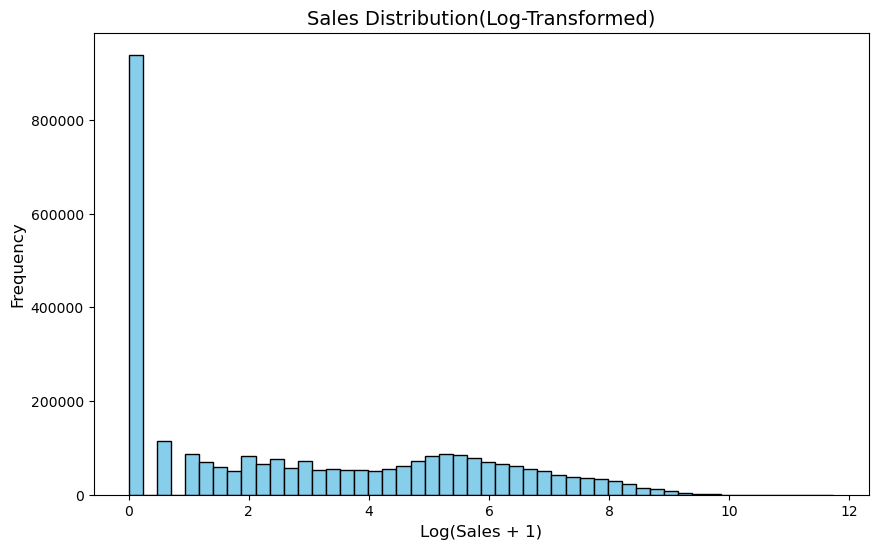

In [90]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10,6))
plt.hist(np.log1p(train_merged['sales']), bins=50, color='skyblue', edgecolor='black')
plt.title('Sales Distribution(Log-Transformed)', fontsize=14)
plt.xlabel('Log(Sales + 1)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.savefig("Sales_distribution.png")
plt.show()

### Sales Distribution (Log Transformed)

This histogram shows the distribution of sales after applying a log transformation to reduce skewness caused by extreme values.

The transformation makes the sales distribution easier to visualize by compressing very large values.

Most sales observations are concentrated at lower ranges, indicating that small sales occur more frequently than very large ones.

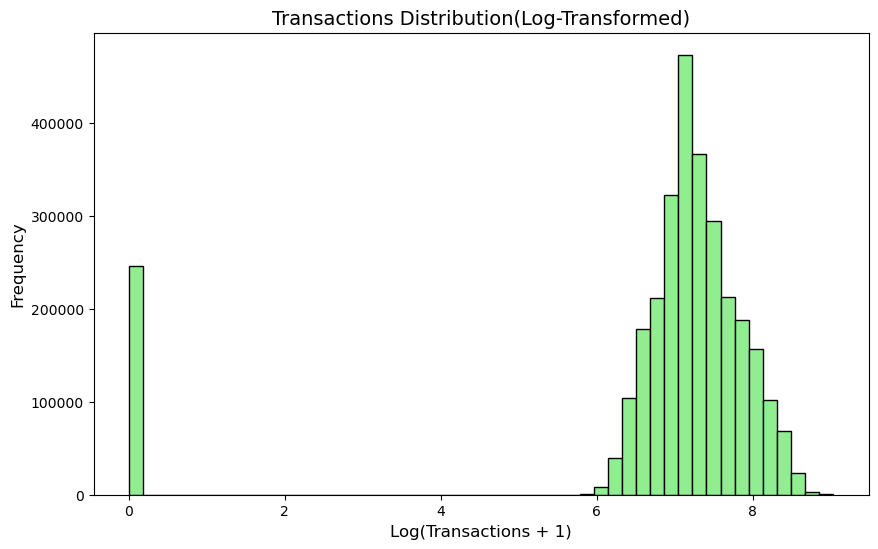

In [98]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10,6))
plt.hist(np.log1p(train_merged['transactions']), bins=50, 
         color='lightgreen', edgecolor='black')
plt.title('Transactions Distribution(Log-Transformed)', fontsize=14)
plt.xlabel('Log(Transactions + 1)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.savefig("Transactions_distribution.png")
plt.show()

### Transactions Distribution

This histogram shows the distribution of stoe transactions after applting a log transformation.
Most stores have moderate transaction levels, while extremely high transaction counts occur less frequently.
The transformation helps reveal the overall pattern by reducing the impact of very large transaction values.

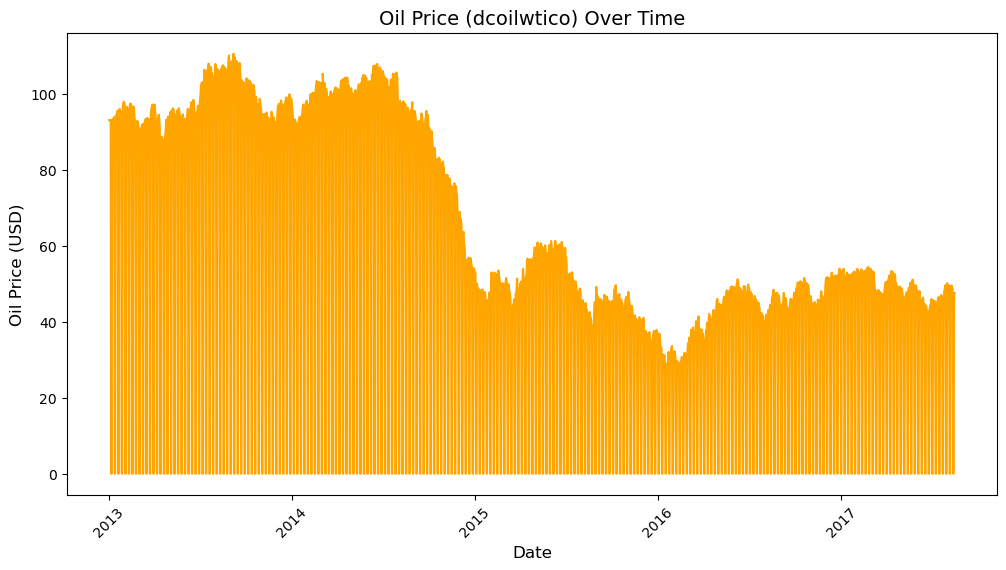

In [94]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(train_merged['date'], train_merged['dcoilwtico'], color='orange')
plt.title('Oil Price (dcoilwtico) Over Time', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Oil Price (USD)', fontsize=12)
plt.xticks(rotation=45)

plt.savefig("Oil_price_trend.png")
plt.show()

### Oil Price Over Time

This line chart shows how oil prices change over time in the dataset. Oil prices may directly influence retail sales through transportation costs and economic conditions.
The plot helps observe trends and fluctuations that could potentially affect store perfomance.

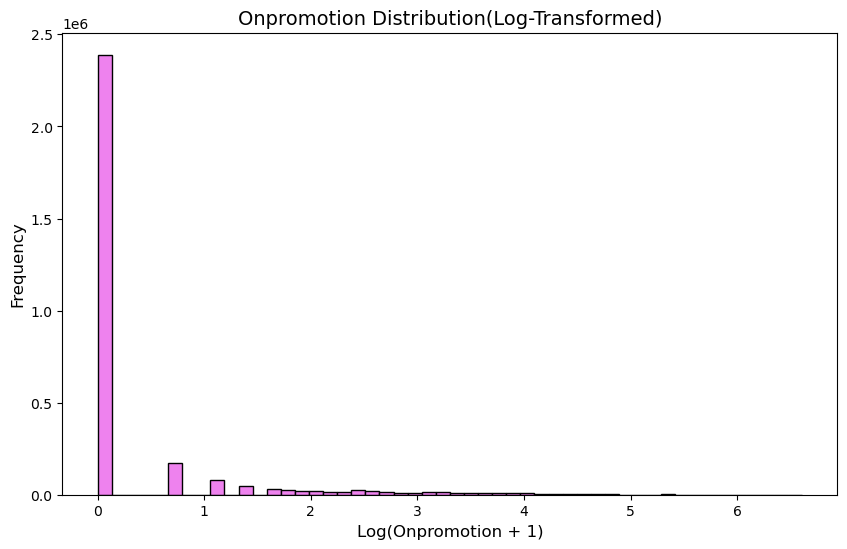

In [95]:
import numpy as np

plt.figure(figsize=(10,6))
plt.hist(np.log1p(train_merged['onpromotion']), bins=50, color='violet', edgecolor='black')
plt.title('Onpromotion Distribution(Log-Transformed)', fontsize=14)
plt.xlabel('Log(Onpromotion + 1)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.savefig("Promotion_distribution.png")
plt.show()

### Onpromotion Distribution

This histogram shows the distribution of the number of items placed on promotion.
Most observations contain a relatively small number of promotions, while large promotional events occur less frequently.
Promotions can influenece customer demand and therefore play an important role in sales forecasting.

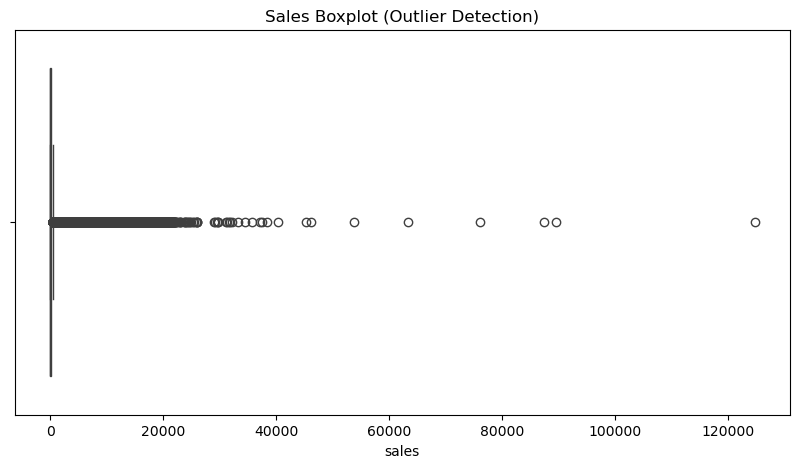

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.boxplot(x=train_merged["sales"])
plt.title("Sales Boxplot (Outlier Detection)")
plt.show()

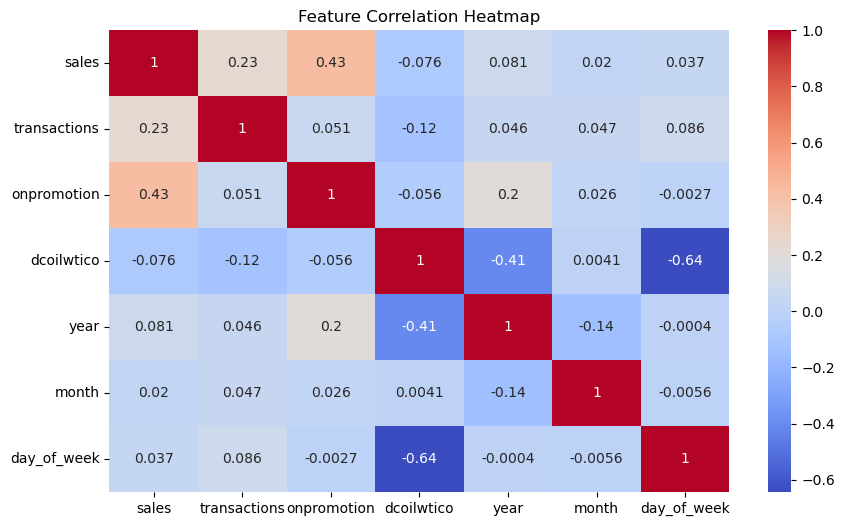

In [96]:
plt.figure(figsize=(10,6))

corr = train_merged[

["sales", "transactions", "onpromotion", "dcoilwtico", "year", "month", "day_of_week"]
].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Feature Correlation Heatmap")
plt.savefig("Correlation_heatmap.png.png")
plt.show()

### Feature Correlation Heatmap

This heatmap shows the correlation between numerical variables in the dataset.
Onpromotion and transactions show the strongest poistive relationship with sales, while oil prices have a very weak negative correlation.

## Model Preparation

Sales data is highly skewed, so a log transformation is applied to stablize variance and improve model performance.

In [65]:
import numpy as np
train_merged['sales_log'] = np.log1p(train_merged['sales'])

In [66]:
train_merged[train_merged['sales'] > 0][['sales', 'sales_log']].head(5)

,sales,sales_log
563,2.00,1.10
564,810.00,6.70
566,180.59,5.20
568,186.00,5.23
569,143.00,4.97


In [67]:
feature_cols = ['transactions', 'onpromotion', 'dcoilwtico', 'year', 'month', 'day_of_week', 'is_holiday', 'family', 'type']

In [68]:
X = pd.get_dummies(train_merged[feature_cols], drop_first=True)
Y = train_merged['sales_log']

In [69]:
print("Before encoding:", train_merged[feature_cols].shape)
print("After encoding:", X.shape)

Before encoding: (3000888, 9)
After encoding: (3000888, 43)


## Model Training

A Linear Regression model is trained to predict sales based on store attributes, promotions, transactions, oil prices, and temoral features.

In [70]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [71]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train, Y_train)

LinearRegression()

In [72]:
y_pred_log = lr_model.predict(X_test)

## Model Evaluation

The model's performance is evaluated using Root Mean Squared Error (RMSE) and visual comparison between actual and predicted sales values.

In [73]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse_log = np.sqrt(mean_squared_error(Y_test, y_pred_log))
print("RMSE (log-space):", rmse_log)

RMSE (log-space): 1.2752203260042385


In [74]:
y_pred_orig = np.expm1(y_pred_log)
y_actual_orig = np.expm1(Y_test)

In [75]:
comparison = pd.DataFrame({'actual_sales': y_actual_orig, 'predicted_sales': y_pred_orig})
comparison = comparison.round(2) 
comparison.head(5)

,actual_sales,predicted_sales
2483653,"2,576.00","3,321.44"
2761877,0.00,91.18
1217988,357.35,124.09
1231938,5.00,3.12
528175,0.00,15.31


In [76]:
rmse_orig = np.sqrt(mean_squared_error(y_actual_orig, y_pred_orig))

In [77]:
print("RMSE (original scale):", rmse_orig)

RMSE (original scale): 94888.2738909099


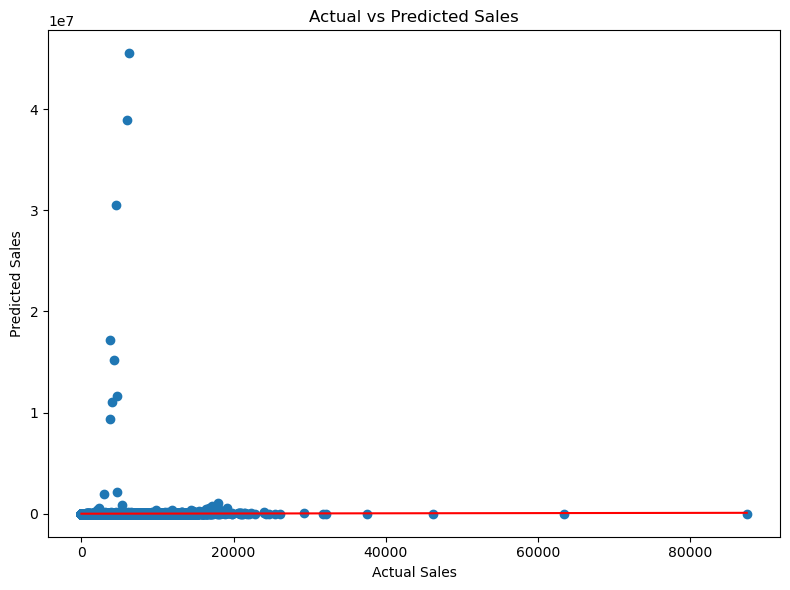

In [99]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_actual_orig, y_pred_orig,)
plt.plot([y_actual_orig.min(), 
          y_actual_orig.max()], 
         [y_actual_orig.min(), 
          y_actual_orig.max()], color='red')

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.tight_layout()
plt.savefig("Actual_vs_predicted.png")
plt.show()

### Actual vs Predicted Sales

This scatter plot compares the model's predicted sales with the actual sales values from the training data.
Points closer to the diagonal line indicate more accurate predictions, while points further away represent prediction errors.
The plot shows that the model captures general sales patterns but struggles with struggles with some extreme values.

## Feature Importance

The coefficients of the trained regression model are examined to understand which features have the strongest influence on predicted sales.

In [79]:
import pandas as pd
coefficients = pd.DataFrame({"Feature": X.columns, 
                             "Coefficient": lr_model.coef_})
coefficients = coefficients.sort_values(by="Coefficient", ascending=False)

coefficients

,Feature,Coefficient
18,family_GROCERY I,5.61
9,family_BEVERAGES,5.19
13,family_CLEANING,4.65
14,family_DAIRY,4.09
11,family_BREAD/BAKERY,3.84
30,family_MEATS,3.46
34,family_POULTRY,3.42
31,family_PERSONAL CARE,3.40
15,family_DELI,3.33
16,family_EGGS,2.90


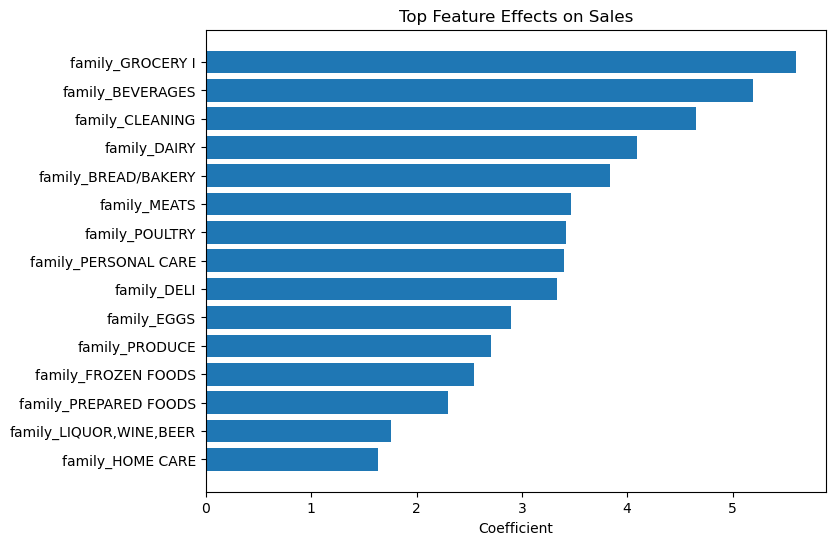

In [100]:
import matplotlib.pyplot as plt

top_features = coefficients.head(15)

plt.figure(figsize=(8,6))
plt.barh(top_features['Feature'], 
         top_features['Coefficient'])
plt.xlabel("Coefficient")
plt.title("Top Feature Effects on Sales")
plt.gca().invert_yaxis()
plt.savefig("Feature_importance.png")
plt.show()

### Top Feature Effects on Sales

This chart shows the features with the largest coefficients in the linear regression model.

Product family categories such as Grocery, Beverages, Cleaning, and Dairy have the strongest positive impact on predicted sales. This indicates that these categories drive a large portion of store revenue.

## Sales Prediction on Test Data

The trained model is applied to the test datset to generate predicted sales values for future observations.

In [81]:
test_merged['year'] = test_merged['date'].dt.year
test_merged['month'] = test_merged['date'].dt.month
test_merged['day'] = test_merged['date'].dt.day
test_merged['day_of_week'] = test_merged['date'].dt.dayofweek

In [82]:
test_merged.head()

,id,date,store_nbr,family,onpromotion,city,state,type,cluster,transactions,dcoilwtico,is_holiday,year,month,day,day_of_week
0,3000888,2017-08-16,1,AUTOMOTIVE,0,Quito,Pichincha,D,13,0.00,46.80,0,2017,8,16,2
1,3000889,2017-08-16,1,BABY CARE,0,Quito,Pichincha,D,13,0.00,46.80,0,2017,8,16,2
2,3000890,2017-08-16,1,BEAUTY,2,Quito,Pichincha,D,13,0.00,46.80,0,2017,8,16,2
3,3000891,2017-08-16,1,BEVERAGES,20,Quito,Pichincha,D,13,0.00,46.80,0,2017,8,16,2
4,3000892,2017-08-16,1,BOOKS,0,Quito,Pichincha,D,13,0.00,46.80,0,2017,8,16,2


In [83]:
feature_cols = ['transactions', 'onpromotion', 'dcoilwtico', 'year', 'month', 'day_of_week', 'is_holiday', 'family', 'type']

In [84]:
X_test = pd.get_dummies(test_merged[feature_cols], drop_first=True)

In [85]:
missing_cols = set(X.columns) - set(X_test.columns)

for col in missing_cols:
    X_test[col] = 0

    X_test = X_test[X.columns]

In [86]:
y_test_pred_log = lr_model.predict(X_test)

In [87]:
y_test_pred = np.expm1(y_test_pred_log)

In [88]:
submission = test_merged[['id']].copy()
submission['predicted_sales'] = y_test_pred

submission['predicted_sales'] = submission['predicted_sales'].clip(lower=0)

submission.head()

,id,predicted_sales
0,3000888,2.71
1,3000889,0.00
2,3000890,1.40
3,3000891,872.05
4,3000892,0.00


Negative predicted sales values were clipped to zero since sales cannot be negative in real retail scenarios.

## Project Conclusion

This project developed a linear regression model to predict retail sales using store transactions, promotions, oil prices and temporal features derived from the date.

Exploratory data analysis revealed that sales are highly skewed, which required log transformation before modeling. The analysis also showed that Promotions and transaction volume have the strongest positive relationships with sales.

The trained model achieved an RMSE of approximately 1.27 in log-space and about 94,888 in the original sales scale. While the model captures general sales patterns, prediction errors remain for extreme sales values.

Overall, this analysis demonstrates how data preprocessing, feature engineering, and regression modeling can be applied to forecast retail sales and extract meaningful business insights.